# Project 3: Principal Component Analysis (PCA) on the `mpg` Dataset — Student Version

In this project, we will use **Principal Component Analysis (PCA)** to study whether a small number of new dimensions can summarize the main variation in automobile characteristics.

This project is centered on four big ideas:

- PCA is an **unsupervised** method.
- PCA works best when features share information through **covariance**.
- Principal components are **new directions**, not original variables.
- PCA is useful for **summarization**, not just visualization.

In [2]:
# load packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---
## Load and prepare the dataset

In [3]:
try:
    cars_df = sns.load_dataset('mpg')
except Exception as e:
    raise RuntimeError(
        "sns.load_dataset('mpg') could not run in this environment. "
        "On a normal internet-connected machine, this line should work. "
        "If needed, download the dataset manually and load it from a local file."
    ) from e

cars_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Before doing PCA, we will remove rows with missing values and define the subset of feature columns used in the analysis.

For this project, we will use these PCA feature columns:

- `cylinders`
- `displacement`
- `horsepower`
- `weight`
- `acceleration`

We will exclude `mpg`, `model_year`, `origin`, and `name` from the PCA feature matrix in order to keep the analysis focused on a selected set of numeric vehicle characteristics.

In [4]:
cars_df = cars_df.dropna().reset_index(drop=True)

pca_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

cars_df[pca_features].head()

,cylinders,displacement,horsepower,weight,acceleration
0,8,307.0,130.0,3504,12.0
1,8,350.0,165.0,3693,11.5
2,8,318.0,150.0,3436,11.0
3,8,304.0,150.0,3433,12.0
4,8,302.0,140.0,3449,10.5


---
# Explore the selected features

## Q1 (5 pt)

Create a pairplot of the selected PCA feature columns.

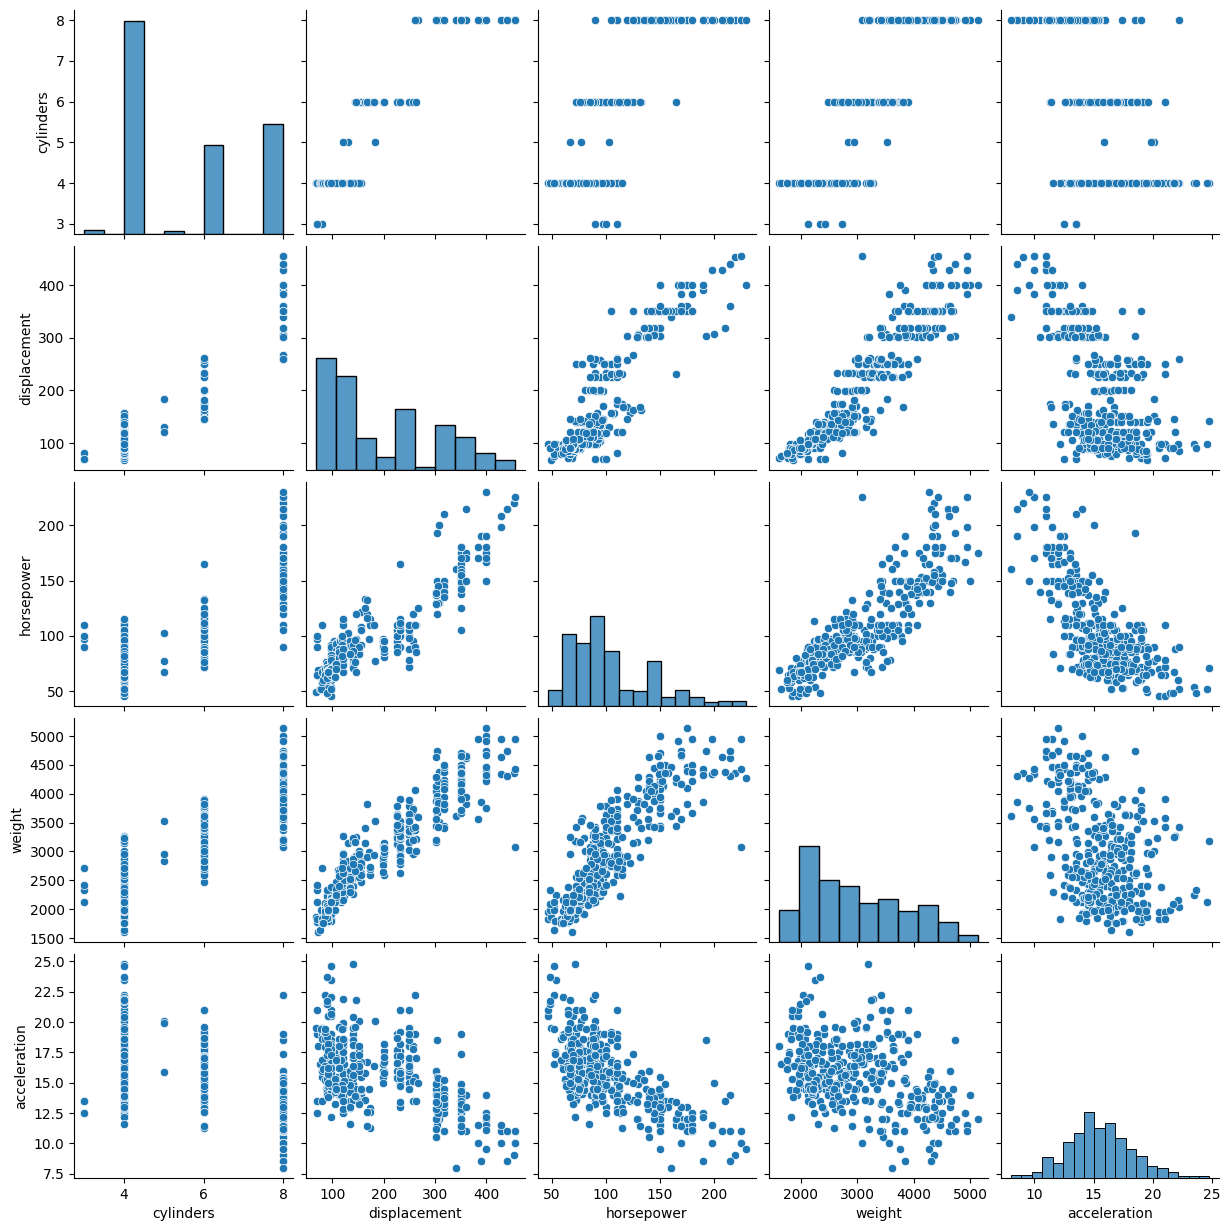

In [5]:
# ANSWER HERE

# Create a pairplot of the selected PCA feature columns.
sns.pairplot(cars_df[pca_features])
plt.show()


## Q2 (5 pt)

Create a correlation heatmap for the selected PCA feature columns.

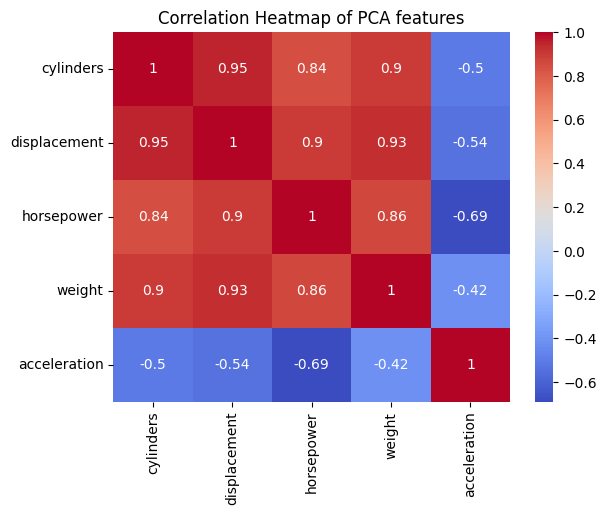

In [6]:
# ANSWER HERE
# Compute the correlation matrix for the selected PCA feature columns.
corr = cars_df[pca_features].corr()
# Then create a correlation heatmap.
sns.heatmap(corr, cmap="coolwarm", annot=True) # red for positive correlation; blue for negative correlation
plt.title("Correlation Heatmap of PCA features")
plt.show()

---
# Why might PCA help here?

## Q3 (5 pt)

**Question:** Based on the pairplot and correlation heatmap, why might PCA be useful for this dataset?

**Answer:** PCA is useful because several of the selected features (cylinders, displacement, horsepower, weight) are highly correlated and therefore contain overlapping information. PCA can rotate the feature space into new orthogonal directions (principal components) that capture most of the variance with fewer dimensions, reducing redundancy and multicollinearity.

## Q4 (5 pt)

**Question:** Which selected features seem to capture related or overlapping information about the cars?

**Answer:** The features that most clearly capture overlapping information are cylinders, displacement, horsepower, and weight (they tend to increase together). Acceleration is related too, but it often behaves differently (it can be less correlated or even negatively related with “size/power” variables depending on the data).

## Q5 (5 pt)

Construct the feature matrix `X` using the selected PCA feature columns and convert it to a NumPy array.

In [7]:
# ANSWER HERE
X = cars_df[pca_features].to_numpy()
# print first 5 rows of X
print(X[:5])

[[   8.   307.   130.  3504.    12. ]
 [   8.   350.   165.  3693.    11.5]
 [   8.   318.   150.  3436.    11. ]
 [   8.   304.   150.  3433.    12. ]
 [   8.   302.   140.  3449.    10.5]]


Your answer should follow this pattern (remember the relationship between variance and covariance we talked about in lab):

\[
\mathrm{Cov}(X_{std}) = \frac{X_{std}^T X_{std}}{n}
\]

where \(n\) is the number of rows (observations) in `X_std`. This is the covariance formula you should use for this project.

---
# Standardize the data

## Q6 (5 pt)

Standardize all columns of `X` using the approach from lab.

In [8]:
# ANSWER HERE
X_mean = np.mean(X, axis=0)
X_std_dev = np.std(X, axis=0)
X_std = (X - X_mean) / X_std_dev

# print first 5 rows of X_std
print(X_std[:5])

[[ 1.48394702  1.07728956  0.66413273  0.62054034 -1.285258  ]
 [ 1.48394702  1.48873169  1.57459447  0.84333403 -1.46672362]
 [ 1.48394702  1.1825422   1.18439658  0.54038176 -1.64818924]
 [ 1.48394702  1.04858429  1.18439658  0.53684535 -1.285258  ]
 [ 1.48394702  1.02944745  0.92426466  0.5557062  -1.82965485]]


## Q7 (5 pt)

Using the standardized feature matrix `X_std`, compute the covariance matrix with the formula

\begin{equation}
  Cov = \frac{(X^TX)}{|X|}
\end{equation}

where $|X|$ is the length of 'X_std'.

Remember that `@` performs matrix multiplication in Python and is equivalent to `np.matmul()`.


In [9]:
# ANSWER HERE
cov_mat = (X_std.T @ X_std) / len(X_std)

# print covariance matrix
print(cov_mat)



[[ 1.          0.9508233   0.84298336  0.89752734 -0.50468338]
 [ 0.9508233   1.          0.897257    0.9329944  -0.5438005 ]
 [ 0.84298336  0.897257    1.          0.86453774 -0.68919551]
 [ 0.89752734  0.9329944   0.86453774  1.         -0.4168392 ]
 [-0.50468338 -0.5438005  -0.68919551 -0.4168392   1.        ]]


## Q8 (5 pt)

Use `np.linalg.eig()` to compute the eigenvalues and eigenvectors of the covariance matrix.

In [10]:
# ANSWER HERE
eigval, eigvec = np.linalg.eig(cov_mat)

# print eigenvalues and eigenvectors
print("Eigenvalues:\n", eigval)
print("\nEigenvectors:\n", eigvec)

Eigenvalues:
 [4.07185982 0.69386125 0.13349305 0.0365175  0.06426839]

Eigenvectors:
 [[ 0.46871748  0.2234786   0.65869995  0.47265527  0.27031946]
 [ 0.4824044   0.17862974  0.18764042 -0.83649107  0.02124108]
 [ 0.47384374 -0.11998855 -0.62757104  0.12194007  0.59359925]
 [ 0.46179021  0.34528638 -0.33449699  0.24715772 -0.70324388]
 [-0.3313787   0.8857363  -0.15865624 -0.03038708  0.28207124]]


**Question:** Why is there a diagonal of 1s in the covariance matrix?

**Answer:** Because you standardized the features to make X_std have mean 0 and variance 1 for each column. The covariance matrix’s diagonal entries are Cov(X_i, X_i)=Var(X_i), so each diagonal entry becomes 1.

## Q9 (5 pt)

Sort the eigenvalues from largest to smallest and reorder the eigenvectors to match. Then list each eigenvalue followed by its associated eigenvector.

In [11]:
# ANSWER HERE
sort_idx = np.argsort(eigval)[::-1]

eigval_sorted = eigval[sort_idx]
eigvec_sorted = eigvec[:, sort_idx]

# Print each eigenvalue with its associated eigenvector.
for i in range(len(eigval_sorted)):
    print(f"Eigenvalue {i+1}: {eigval_sorted[i]}")
    print(f"Eigenvector {i+1}: {eigvec_sorted[:, i]}\n")

Eigenvalue 1: 4.071859815071808
Eigenvector 1: [ 0.46871748  0.4824044   0.47384374  0.46179021 -0.3313787 ]

Eigenvalue 2: 0.6938612487004463
Eigenvector 2: [ 0.2234786   0.17862974 -0.11998855  0.34528638  0.8857363 ]

Eigenvalue 3: 0.13349304631676903
Eigenvector 3: [ 0.65869995  0.18764042 -0.62757104 -0.33449699 -0.15865624]

Eigenvalue 4: 0.0642683911407768
Eigenvector 4: [ 0.27031946  0.02124108  0.59359925 -0.70324388  0.28207124]

Eigenvalue 5: 0.03651749877019737
Eigenvector 5: [ 0.47265527 -0.83649107  0.12194007  0.24715772 -0.03038708]



## Q10 (5 pt)

**Question:** Why do we sort the eigenvalues from largest to smallest before identifying the principal components? (Default in Numpy)

**Answer:**  We sort eigenvalues largest to smallest because each eigenvalue measures how much variance its eigenvector (principal component direction) explains. The principal components are defined in order of maximum explained variance, so the largest eigenvalue corresponds to PC1, the next largest to PC2, etc.

---
# Explained variance

## Q11 (5 pt)

Calculate the explained variance percentage for each principal component.

For eigenvalues $\{\lambda_1, \lambda_2, ..., \lambda_n\}$, the explained variance of eigenvalue $\lambda_j$ is

$$
100 \times \frac{\lambda_j}{\sum_{i=1}^{n}\lambda_i}
$$

In [ ]:
# ANSWER HERE
explained_variance = eigval_sorted / np.sum(eigval_sorted)
for i in range(len(explained_variance)):
    print(f"Principal Component {i+1} explains {explained_variance[i]:.4f} of the variance.")

Principal Component 1 explains 0.8144 of the variance.
Principal Component 2 explains 0.1388 of the variance.
Principal Component 3 explains 0.0267 of the variance.
Principal Component 4 explains 0.0129 of the variance.
Principal Component 5 explains 0.0073 of the variance.


## Q12 (5 pt)

Compute the cumulative explained variance using `np.cumsum()`.

In [14]:
# ANSWER HERE
c_explained_variance = np.cumsum(explained_variance)
print("Cumulative Explained Variance:", c_explained_variance)


Cumulative Explained Variance: [0.81437196 0.95314421 0.97984282 0.9926965  1.        ]


**Check-in:** What should the sum of your explained variance values equal? Why?

The sum of the explained variance values should equal 1 because they represent proportions of the total variance in the data. Together they account for all the variability and therefore should sum to 1.

## Q13 (5 pt)

Plot cumulative explained variance versus number of components.

Hints:
- The x-axis should be the component numbers (1 through the number of selected features)
- The y-axis should be `c_explained_variance`
- Use `plt.plot(..., '-o')` to place dots on the line graph


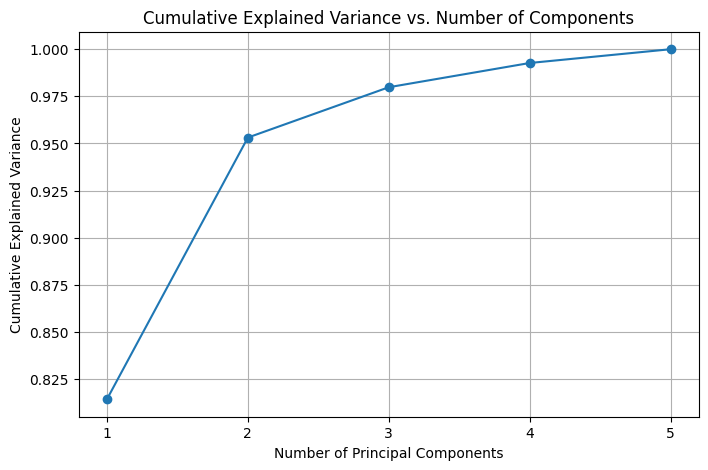

In [15]:
# ANSWER HERE
# Plot cumulative explained variance versus number of components.

n_features = X.shape[1]
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_features + 1), c_explained_variance, marker='o')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, n_features + 1))
plt.grid()
plt.show()





---
# Projecting the data onto principal components

Once we identify the principal component directions, we can express each car in the new reduced coordinate system defined by those directions.

Create the **projection matrix**, `W`, who has columns PC1 and PC2. PC1 and PC2 are the $2$ eigenvectors we want to graph associated with the two largest eigenvectors. (PC1 vs PC2, aka the eigenvectors associated with the top 2 largest eigenvalues)

\begin{gather}
  W = \begin{pmatrix}
    \vert & \vert \\
    PC1 & PC2 \\
    \vert & \vert
  \end{pmatrix}
\end{gather}


## Q14 (5 pt)

Construct a matrix whose columns are the eigenvectors corresponding to PC1 and PC2. Use the **sorted** eigenvectors.

In [16]:
# ANSWER HERE
W = eigvec_sorted[:, :2]

#print the projection matrix W
print("Projection matrix W: \n", W)

Projection matrix W: 
 [[ 0.46871748  0.2234786 ]
 [ 0.4824044   0.17862974]
 [ 0.47384374 -0.11998855]
 [ 0.46179021  0.34528638]
 [-0.3313787   0.8857363 ]]


## Q15 (5 pt)

Use your projection matrix $W$ to project `X_std` onto a 2-dimensional subspace. Remember to check matrix shapes and multiplication order.

In [17]:
# ANSWER HERE
Z = X_std @ W

# print first 5 rows of Z
print("First 5 rows of Z:\n", Z[:5])

First 5 rows of Z:
 [[ 2.24240284 -0.47975751]
 [ 3.03531871 -0.59930975]
 [ 2.62295217 -0.872521  ]
 [ 2.43642953 -0.57620957]
 [ 2.49304723 -1.02409478]]


---
# Interpreting the principal components

Each principal component is a weighted combination of the original features. The entries of the eigenvectors show how strongly each original feature contributes to a principal component. Larger absolute values indicate stronger contribution. Features with the same sign in a component tend to move together in that direction, while opposite signs suggest a contrast.

## Q16 (5 pt)

Create a table showing how each original feature contributes to PC1 and PC2.

In [18]:
# ANSWER HERE
feature_weight_table = pd.DataFrame(W, index=pca_features, columns=['PC1', 'PC2'])
print(feature_weight_table)


                   PC1       PC2
cylinders     0.468717  0.223479
displacement  0.482404  0.178630
horsepower    0.473844 -0.119989
weight        0.461790  0.345286
acceleration -0.331379  0.885736


---
# Final PCA interpretation

## Q17 (5 pt)

**Question:** Based on your feature-contribution table, which original features contribute most strongly to PC1? What does PC1 appear to represent?

**Answer:** 

## Q18 (5 pt)

**Question:** Based on your feature-contribution table, which original features contribute most strongly to PC2? What does PC2 appear to represent?

**Answer:** 

## Q19 (10 pt)

**Question:** Using your explained variance results and your PC1/PC2 interpretations, do the first two principal components provide a useful summary of this dataset? What is gained by reducing the data to two dimensions, and what information may be lost?

**Answer:** 